# Diverse Chain Selector for VelocityFM Overfit Run

Picks **N diverse chains** from your existing `.npz` dataset using a **feature fingerprint + greedy max-min selection** strategy.

Each chain is described by:
- Sequence length
- Amino acid composition (20-dim frequency vector)
- Secondary structure fractions (helix / strand / coil) estimated from backbone torsions
- Mean and std of Cα RMSF across MD frames (conformational flexibility)
- Mean omega std (backbone rigidity signal)

Greedy max-min then picks chains that are maximally different from each other in this feature space, guaranteeing the subset covers different lengths, compositions, flexibilities, and fold types.

**No internet / ESM / PDB lookup required — works entirely from your NPZs.**

## 0) Install + Mount

In [14]:
!pip -q install numpy scipy scikit-learn matplotlib seaborn

In [15]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1) Configuration — Edit This Block Only

In [16]:
import os

# ── Path to your folder of .npz files (the train split) ───────────────────────
NPZ_DIR = "/content/drive/MyDrive/af_native_dynamics_predictor/data/processed/MD_Simulation/V7_atom14_openfold_npz"

# If your train npzs live inside a zip, set this and the cell below will unzip
TRAIN_ZIP = os.path.join(NPZ_DIR, "train_R1.zip")   # set to None if already unzipped
LOCAL_NPZ_DIR = "/content/npz_train"              # local working dir (fast I/O)

# ── Selection settings ────────────────────────────────────────────────────────
N_CHAINS    = 8       # how many diverse chains you want
RANDOM_SEED = 42

# Output
OUT_TXT  = "/content/drive/MyDrive/af_native_dynamics_predictor/data/processed/MD_Simulation/V7_atom14_openfold_npz/overfit_subset/diverse_chains.txt"    # one chain_id per line
OUT_CSV  = "/content/drive/MyDrive/af_native_dynamics_predictor/data/processed/MD_Simulation/V7_atom14_openfold_npz/overfit_subset/diverse_chains.csv"    # with feature values for inspection

os.makedirs(LOCAL_NPZ_DIR, exist_ok=True)

## 2) Unzip Train Split (skip if already unzipped)

In [17]:
import zipfile
from tqdm.auto import tqdm

def unzip_if_needed(zip_path, out_dir):
    marker = os.path.join(out_dir, ".unzipped_done")
    if os.path.exists(marker):
        return

    print(f"[UNZIP] Extracting {zip_path} -> {out_dir}")

    with zipfile.ZipFile(zip_path, "r") as z:
        # Get the list of files to extract
        members = z.infolist()

        # specific TQDM settings for bytes
        with tqdm(total=sum(m.file_size for m in members), unit='B', unit_scale=True, desc="Extracting") as pbar:
            for member in members:
                z.extract(member, out_dir)
                pbar.update(member.file_size)

    with open(marker, "w") as f:
        f.write("ok")

def copy_with_progress(src, dst):
    size = os.path.getsize(src)
    with open(src, 'rb') as fsrc, open(dst, 'wb') as fdst:
        with tqdm(total=size, unit='B', unit_scale=True, desc=f"Copying {os.path.basename(src)}") as pbar:
            while True:
                chunk = fsrc.read(1024 * 1024)
                if not chunk: break
                fdst.write(chunk)
                pbar.update(len(chunk))

copy_with_progress(TRAIN_ZIP, "/content/test.zip")
unzip_if_needed("/content/test.zip", LOCAL_NPZ_DIR)

npz_files = sorted([f for f in os.listdir(LOCAL_NPZ_DIR) if f.endswith(".npz")])
print(f"Found {len(npz_files)} .npz files")

Copying train_R1.zip:   0%|          | 0.00/14.2G [00:00<?, ?B/s]

[UNZIP] Extracting /content/test.zip -> /content/npz_train


Extracting:   0%|          | 0.00/14.3G [00:00<?, ?B/s]

Found 570 .npz files


## 3) Extract Feature Fingerprints from Each NPZ

For each chain we compute a compact descriptor that captures:
- **Length** (log-scaled so a 50-residue and 250-residue chain aren't artificially far apart)
- **AA composition** (20-dim, how much of each amino acid type)
- **SS fractions** (helix/strand/coil from φ/ψ Ramachandran regions — no DSSP needed)
- **Cα RMSF** mean and std (how flexible the chain is across MD frames)
- **Omega std** mean (backbone planarity / rigidity)
- **Torsion variance** (average angular variance across all torsion channels)

In [21]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import warnings

AA_ORDER = "ARNDCQEGHILKMFPSTWYV"  # OpenFold restypes order

def ramachandran_ss_fractions(phi, psi, mask):
    """
    Estimate helix / strand / coil fractions from phi-psi.
    Uses mean angles averaged over all frames before classifying.
    phi, psi: [F, N] in radians; mask: [N] boolean
    """
    if phi.shape[0] == 0 or mask.sum() == 0:
        return 0.33, 0.33, 0.34

    # Circular mean per residue over frames
    phi_m = np.arctan2(np.sin(phi[:, mask]).mean(0), np.cos(phi[:, mask]).mean(0))
    psi_m = np.arctan2(np.sin(psi[:, mask]).mean(0), np.cos(psi[:, mask]).mean(0))

    phi_d = np.degrees(phi_m)
    psi_d = np.degrees(psi_m)

    # Helix:  phi ∈ [-100, -30], psi ∈ [-70, 0]
    helix  = ((phi_d > -100) & (phi_d < -30) & (psi_d > -70) & (psi_d < 10))
    # Strand: phi ∈ [-180, -40], psi ∈ [60, 180] or [-180, -150]
    strand = ((phi_d > -180) & (phi_d < -40) & ((psi_d > 60) | (psi_d < -150)))
    coil   = ~(helix | strand)

    n = len(phi_d)
    return helix.sum()/n, strand.sum()/n, coil.sum()/n


def extract_fingerprint(npz_path):
    """
    Returns a dict of scalar/vector features, or None on error.

    Actual NPZ shapes (confirmed from extraction notebook):
      aatype          [N]              int64
      atom14_pos      [F, N, 14, 3]   float32/float16
      atom14_mask     [F, N, 14]      uint8   <- frame dim present!
      torsion_angles  [F, N, 7]       float32
      torsion_mask    [F, N, 7]       uint8   <- frame dim present!
      frame_R         [F, N, 3, 3]
      frame_t         [F, N, 3]
      frame_mask      [F, N]
    """
    try:
        d = np.load(npz_path, allow_pickle=False)

        # ── Debug: print shapes once ──────────────────────────────────────────
        if not hasattr(extract_fingerprint, '_shapes_printed'):
            extract_fingerprint._shapes_printed = True
            print("[DEBUG] First NPZ key shapes:")
            for k in ["aatype", "atom14_pos", "atom14_mask",
                      "torsion_angles", "torsion_mask", "frame_t"]:
                if k in d:
                    print(f"  {k}: {d[k].shape}")

        # ── Basic ────────────────────────────────────────────────────────────
        aatype = d["aatype"].astype(int)    # [N]
        N      = len(aatype)
        if N < 10:
            return None

        # ── AA composition ───────────────────────────────────────────────────
        aa_counts = np.bincount(aatype, minlength=20).astype(float)
        aa_freq   = aa_counts / aa_counts.sum()

        # ── Torsion angles: [F, N, 7] ─────────────────────────────────────────
        tors  = d["torsion_angles"].astype(np.float32)  # [F, N, 7]
        tmask = d["torsion_mask"].astype(bool)           # [F, N, 7]
        F     = tors.shape[0]

        # Static per-residue mask: a torsion is valid if it's valid in ANY frame
        # shape [N, 7] — used for SS classification and variance
        tmask_static = tmask.any(axis=0)   # [N, 7]

        phi_mask = tmask_static[:, 1]   # [N]
        psi_mask = tmask_static[:, 2]   # [N]
        bb_mask  = phi_mask & psi_mask  # [N]

        phi = tors[:, :, 1]   # [F, N]
        psi = tors[:, :, 2]   # [F, N]
        f_helix, f_strand, f_coil = ramachandran_ss_fractions(phi, psi, bb_mask)

        # ── Cα RMSF: atom14_pos [F, N, 14, 3], atom14_mask [F, N, 14] ────────
        atom14_pos  = d["atom14_pos"].astype(np.float32)  # [F, N, 14, 3]
        atom14_mask = d["atom14_mask"].astype(bool)       # [F, N, 14]

        # Static Cα mask: valid if present in ANY frame
        ca_mask = atom14_mask[:, :, 1].any(axis=0)  # [N]
        ca_pos  = atom14_pos[:, :, 1, :]            # [F, N, 3]

        if ca_mask.sum() > 0 and F > 1:
            ca_valid  = ca_pos[:, ca_mask, :]        # [F, Nv, 3]
            rmsf      = ca_valid.std(axis=0)         # [Nv, 3]
            rmsf_mag  = np.linalg.norm(rmsf, axis=-1)
            rmsf_mean = float(rmsf_mag.mean())
            rmsf_std  = float(rmsf_mag.std())
        else:
            rmsf_mean = rmsf_std = 0.0

        # ── Omega std (backbone planarity / rigidity) ─────────────────────────
        omg_mask = tmask_static[:, 0]   # [N]
        if omg_mask.sum() > 0 and F > 1:
            omg = tors[:, omg_mask, 0]   # [F, Nv]
            omg_std_per_res = np.sqrt(
                1 - np.clip(np.cos(omg).mean(0)**2 + np.sin(omg).mean(0)**2, 0, 1)
            )
            omega_std_mean = float(omg_std_per_res.mean())
        else:
            omega_std_mean = 0.0

        # ── Overall torsion angular variance ─────────────────────────────────
        if F > 1:
            R_vec = np.stack([
                np.cos(tors[:, :, k]).mean(0)**2 + np.sin(tors[:, :, k]).mean(0)**2
                for k in range(7)
            ], axis=-1)   # [N, 7]  (1=perfectly rigid, 0=random)
            tors_var = float(1 - R_vec[tmask_static].mean())
        else:
            tors_var = 0.0

        return {
            "chain_id"    : os.path.splitext(os.path.basename(npz_path))[0],
            "n_residues"  : N,
            "n_frames"    : F,
            "aa_freq"     : aa_freq,
            "f_helix"     : f_helix,
            "f_strand"    : f_strand,
            "f_coil"      : f_coil,
            "rmsf_mean"   : rmsf_mean,
            "rmsf_std"    : rmsf_std,
            "omega_std"   : omega_std_mean,
            "torsion_var" : tors_var,
        }
    except Exception as e:
        print(f"[WARN] {os.path.basename(npz_path)}: {e}")
        return None


print("Extracting fingerprints ...")
records = []
for fname in tqdm(npz_files):
    fp = extract_fingerprint(os.path.join(LOCAL_NPZ_DIR, fname))
    if fp is not None:
        records.append(fp)

print(f"\nSuccessfully fingerprinted {len(records)}/{len(npz_files)} chains")

Extracting fingerprints ...


  0%|          | 0/570 [00:00<?, ?it/s]

[DEBUG] First NPZ key shapes:
  aatype: (130,)
  atom14_pos: (1001, 130, 14, 3)
  atom14_mask: (1001, 130, 14)
  torsion_angles: (1001, 130, 7)
  torsion_mask: (1001, 130, 7)
  frame_t: (1001, 130, 3)

Successfully fingerprinted 570/570 chains


## 4) Build Feature Matrix + Normalize

In [23]:
from sklearn.preprocessing import StandardScaler
import numpy as np

chain_ids = [r["chain_id"] for r in records]

AA_W   = 1.0
SS_W   = 2.0
RMSF_W = 2.0
LEN_W  = 1.5

raw_rows = []
for r in records:
    row = np.concatenate([
        np.asarray(r["aa_freq"], dtype=np.float32) * AA_W,                          # (20,)
        np.asarray([r["f_helix"], r["f_strand"], r["f_coil"]], dtype=np.float32) * SS_W,  # (3,)
        np.asarray([r["rmsf_mean"], r["rmsf_std"]], dtype=np.float32) * RMSF_W,            # (2,)
        np.asarray([r["omega_std"]], dtype=np.float32),                             # (1,)
        np.asarray([r["torsion_var"]], dtype=np.float32),                           # (1,)
        np.asarray([np.log1p(r["n_residues"]) * LEN_W], dtype=np.float32),          # (1,)
    ])
    raw_rows.append(row)

X_raw = np.stack(raw_rows, axis=0)   # [n_chains, 28]

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f"Feature matrix: {X.shape}  (chains × features)")
print(f"Feature std before norm: min={X_raw.std(0).min():.4f}  max={X_raw.std(0).max():.4f}")
print(f"After normalisation  mean={X.mean():.3f}  std={X.std():.3f}  (expect ~0 and ~1)")

Feature matrix: (570, 28)  (chains × features)
Feature std before norm: min=0.0066  max=1.3156
After normalisation  mean=-0.000  std=1.000  (expect ~0 and ~1)


## 5) Greedy Max-Min Diverse Selection

Algorithm:
1. Seed with the chain whose feature vector is closest to the global centroid (most "average" chain — guarantees the set includes at least one typical representative)
2. Repeat: pick the chain whose **minimum distance** to any already-selected chain is **maximum** (maximally far from everything chosen so far)
3. Stop when N_CHAINS selected

This is the standard farthest-point / Gonzalez algorithm and gives a 2-approximation to the optimal k-center problem.

In [24]:
from scipy.spatial.distance import cdist

def greedy_max_min_select(X, n, seed_idx=None):
    """
    Greedy farthest-point sampling.
    Returns list of selected indices (length n).
    """
    n_total = X.shape[0]
    assert n <= n_total, f"Requested {n} chains but only {n_total} available"

    if seed_idx is None:
        # Seed: chain closest to centroid
        centroid = X.mean(0, keepdims=True)
        seed_idx = int(cdist(X, centroid).argmin())

    selected   = [seed_idx]
    # min_dists[i] = distance from chain i to its closest selected chain
    min_dists  = cdist(X, X[selected]).min(axis=1)   # [n_total]

    for step in range(1, n):
        # Pick the chain farthest from all already-selected chains
        next_idx = int(np.argmax(min_dists))
        selected.append(next_idx)
        # Update min_dists
        new_dists  = cdist(X, X[[next_idx]]).squeeze(1)
        min_dists  = np.minimum(min_dists, new_dists)
        print(f"  Step {step}: added '{chain_ids[next_idx]}' "
              f"(min-dist-to-set = {cdist(X[[next_idx]], X[selected[:-1]]).min():.3f})")

    return selected


print(f"Running greedy max-min selection for {N_CHAINS} chains ...")
selected_idx = greedy_max_min_select(X, N_CHAINS)

selected_chains  = [chain_ids[i]  for i in selected_idx]
selected_records = [records[i]    for i in selected_idx]

print(f"\n✅ Selected {len(selected_chains)} chains:")
for cid in selected_chains:
    print(f"  {cid}")

Running greedy max-min selection for 8 chains ...
  Step 1: added '2gh0_D_R1' (min-dist-to-set = 11.029)
  Step 2: added '5hqh_A_R1' (min-dist-to-set = 10.839)
  Step 3: added '1kpt_A_R1' (min-dist-to-set = 10.083)
  Step 4: added '7jrq_A_R1' (min-dist-to-set = 9.521)
  Step 5: added '3o3x_A_R1' (min-dist-to-set = 9.333)
  Step 6: added '4fbs_A_R1' (min-dist-to-set = 9.033)
  Step 7: added '3ld7_B_R1' (min-dist-to-set = 9.007)

✅ Selected 8 chains:
  2igi_A_R1
  2gh0_D_R1
  5hqh_A_R1
  1kpt_A_R1
  7jrq_A_R1
  3o3x_A_R1
  4fbs_A_R1
  3ld7_B_R1


## 6) Summary Table

In [25]:
import pandas as pd

rows = []
for r in selected_records:
    top3_aa = sorted(zip(r["aa_freq"], list(AA_ORDER)), reverse=True)[:3]
    top3_str = "/".join(f"{aa}({100*freq:.0f}%)" for freq, aa in top3_aa)
    rows.append({
        "chain_id"     : r["chain_id"],
        "n_residues"   : r["n_residues"],
        "n_frames"     : r["n_frames"],
        "helix%"       : f"{100*r['f_helix']:.0f}",
        "strand%"      : f"{100*r['f_strand']:.0f}",
        "coil%"        : f"{100*r['f_coil']:.0f}",
        "rmsf_mean_A"  : f"{r['rmsf_mean']:.3f}",
        "rmsf_std_A"   : f"{r['rmsf_std']:.3f}",
        "omega_std"    : f"{r['omega_std']:.3f}",
        "torsion_var"  : f"{r['torsion_var']:.3f}",
        "top3_aa"      : top3_str,
    })

df_sel = pd.DataFrame(rows)
print(df_sel.to_string(index=False))

 chain_id  n_residues  n_frames helix% strand% coil% rmsf_mean_A rmsf_std_A omega_std torsion_var              top3_aa
2igi_A_R1         180      1001     53      35    11       0.938      0.679     0.122       0.186   L(11%)/E(9%)/A(9%)
2gh0_D_R1         101      1001     24      64    12       4.182      1.880     0.140       0.223 R(15%)/S(12%)/L(12%)
5hqh_A_R1         109      1001     18      74     8       3.160      2.678     0.138       0.269 V(17%)/S(11%)/K(10%)
1kpt_A_R1         105      1001     35      51    14       0.563      0.286     0.123       0.144 G(14%)/N(10%)/S(10%)
7jrq_A_R1         131      1001     85      10     5       2.253      2.494     0.114       0.282 E(15%)/L(14%)/Q(12%)
3o3x_A_R1         198      1001     86       7     7       0.853      0.542     0.108       0.216 Q(16%)/L(15%)/G(11%)
4fbs_A_R1         137      1001     80      15     5       1.486      1.533     0.115       0.204  S(16%)/A(12%)/T(8%)
3ld7_B_R1         101      1001     15      65  

## 7) Visualise Coverage in PCA Space

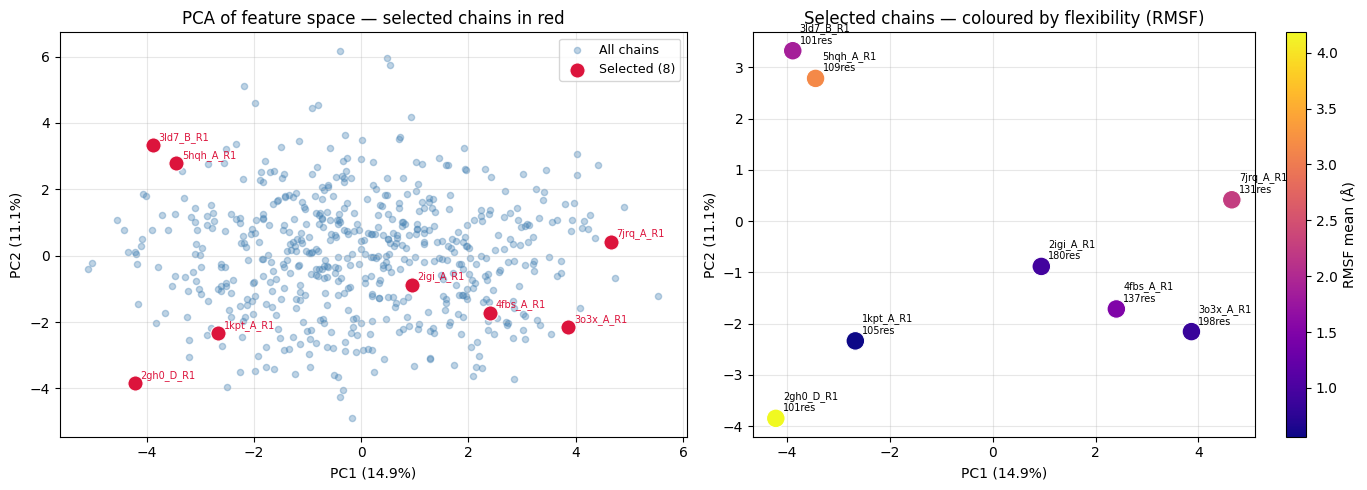

Saved: /content/drive/MyDrive/af_native_dynamics_predictor/data/processed/MD_Simulation/V7_atom14_openfold_npz/overfit_subset/diverse_chain_pca.png


In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA

pca  = PCA(n_components=2, random_state=RANDOM_SEED)
X2   = pca.fit_transform(X)
var  = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: all chains + selected highlighted ─────────────────────────────────
ax = axes[0]
ax.scatter(X2[:, 0], X2[:, 1], s=20, alpha=0.35, c="steelblue", label="All chains")

sel_xy = X2[selected_idx]
ax.scatter(sel_xy[:, 0], sel_xy[:, 1], s=120, c="crimson", zorder=5,
           edgecolors="white", linewidths=0.8, label=f"Selected ({N_CHAINS})")

for i, idx in enumerate(selected_idx):
    ax.annotate(chain_ids[idx], X2[idx], fontsize=7,
                xytext=(4, 4), textcoords="offset points", color="crimson")

ax.set_xlabel(f"PC1 ({100*var[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({100*var[1]:.1f}%)")
ax.set_title("PCA of feature space — selected chains in red")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── Right: selected chains coloured by RMSF mean ────────────────────────────
ax2 = axes[1]
rmsf_vals = np.array([r["rmsf_mean"] for r in selected_records])
sc = ax2.scatter(sel_xy[:, 0], sel_xy[:, 1], s=180,
                 c=rmsf_vals, cmap="plasma", zorder=5,
                 edgecolors="white", linewidths=0.8)
plt.colorbar(sc, ax=ax2, label="RMSF mean (Å)")

for i, idx in enumerate(selected_idx):
    ax2.annotate(
        f"{chain_ids[idx]}\n{selected_records[i]['n_residues']}res",
        X2[idx], fontsize=7,
        xytext=(5, 5), textcoords="offset points"
    )

ax2.set_xlabel(f"PC1 ({100*var[0]:.1f}%)")
ax2.set_ylabel(f"PC2 ({100*var[1]:.1f}%)")
ax2.set_title("Selected chains — coloured by flexibility (RMSF)")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/af_native_dynamics_predictor/data/processed/MD_Simulation/V7_atom14_openfold_npz/overfit_subset/diverse_chain_pca.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: /content/drive/MyDrive/af_native_dynamics_predictor/data/processed/MD_Simulation/V7_atom14_openfold_npz/overfit_subset/diverse_chain_pca.png")

## 8) Visualise Selected Chain Properties Side-by-Side

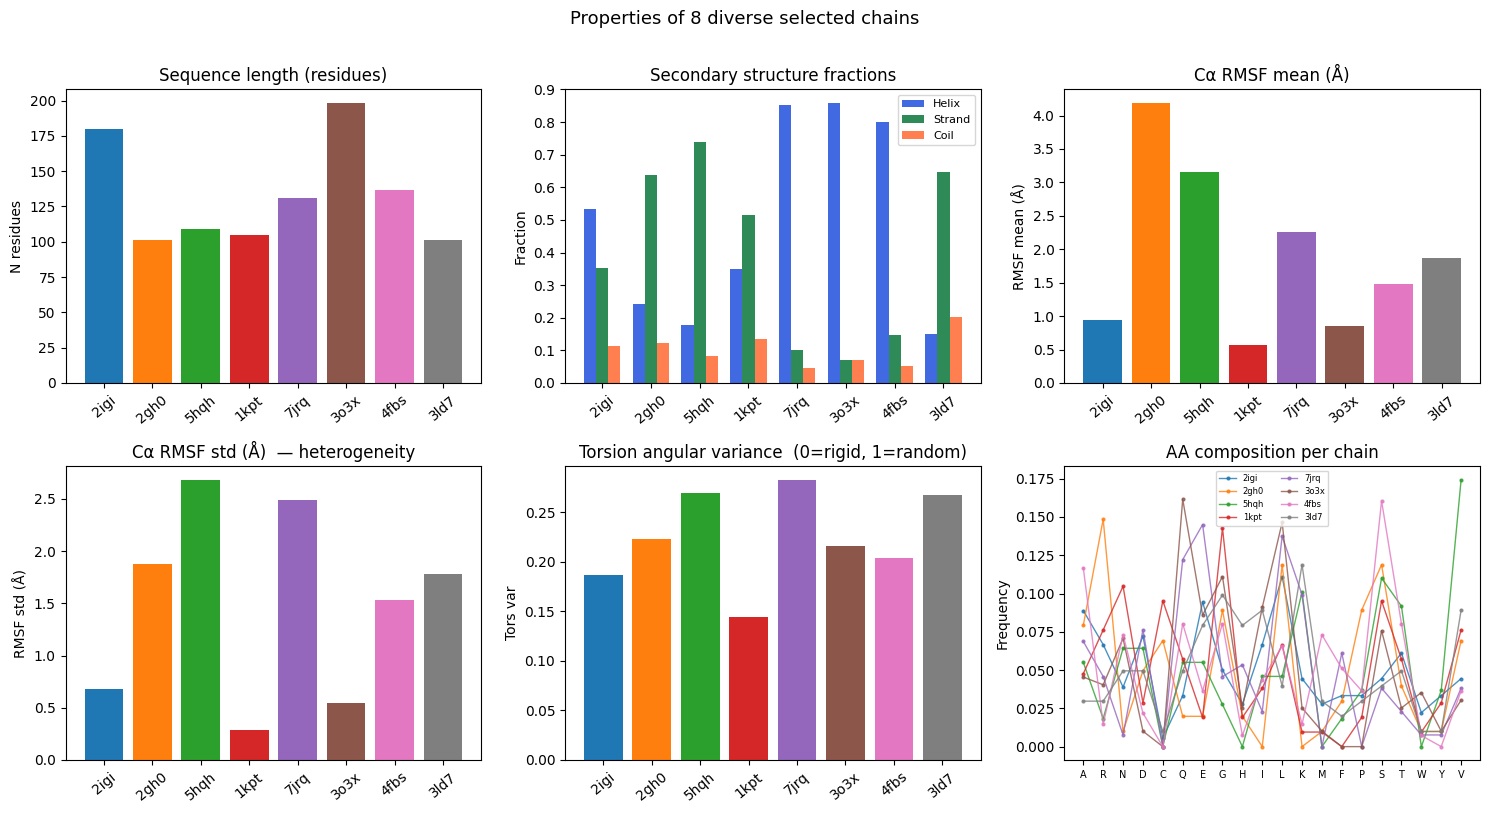

Saved: /content/drive/MyDrive/af_native_dynamics_predictor/data/processed/MD_Simulation/V7_atom14_openfold_npz/overfit_subset/diverse_chain_properties.png


In [31]:
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
labels = [r["chain_id"] for r in selected_records]
short  = [l.split("_")[0] if "_" in l else l[:8] for l in labels]

palette = sns.color_palette("tab10", N_CHAINS)

# 1) Length
ax = axes[0]
ax.bar(short, [r["n_residues"] for r in selected_records], color=palette)
ax.set_title("Sequence length (residues)")
ax.set_ylabel("N residues")
ax.tick_params(axis='x', rotation=40)

# 2) SS fractions
ax = axes[1]
x   = np.arange(N_CHAINS)
w   = 0.25
ax.bar(x - w, [r["f_helix"]  for r in selected_records], w, label="Helix",  color="royalblue")
ax.bar(x,     [r["f_strand"] for r in selected_records], w, label="Strand", color="seagreen")
ax.bar(x + w, [r["f_coil"]   for r in selected_records], w, label="Coil",   color="coral")
ax.set_xticks(x); ax.set_xticklabels(short, rotation=40)
ax.set_title("Secondary structure fractions")
ax.legend(fontsize=8)
ax.set_ylabel("Fraction")

# 3) RMSF mean
ax = axes[2]
ax.bar(short, [r["rmsf_mean"] for r in selected_records], color=palette)
ax.set_title("Cα RMSF mean (Å)")
ax.set_ylabel("RMSF mean (Å)")
ax.tick_params(axis='x', rotation=40)

# 4) RMSF std
ax = axes[3]
ax.bar(short, [r["rmsf_std"] for r in selected_records], color=palette)
ax.set_title("Cα RMSF std (Å)  — heterogeneity")
ax.set_ylabel("RMSF std (Å)")
ax.tick_params(axis='x', rotation=40)

# 5) Torsion variance
ax = axes[4]
ax.bar(short, [r["torsion_var"] for r in selected_records], color=palette)
ax.set_title("Torsion angular variance  (0=rigid, 1=random)")
ax.set_ylabel("Tors var")
ax.tick_params(axis='x', rotation=40)

# 6) AA composition radar-ish (just top AAs as bar)
ax = axes[5]
aa_matrix = np.array([r["aa_freq"] for r in selected_records])  # [N_CHAINS, 20]
for i, (row, col) in enumerate(zip(aa_matrix, palette)):
    ax.plot(list(AA_ORDER), row, marker=".", ms=4, lw=1, alpha=0.8, color=col, label=short[i])
ax.set_title("AA composition per chain")
ax.set_ylabel("Frequency")
ax.tick_params(axis='x', labelsize=7)
ax.legend(fontsize=6, ncol=2)

plt.suptitle(f"Properties of {N_CHAINS} diverse selected chains", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/af_native_dynamics_predictor/data/processed/MD_Simulation/V7_atom14_openfold_npz/overfit_subset/diverse_chain_properties.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: /content/drive/MyDrive/af_native_dynamics_predictor/data/processed/MD_Simulation/V7_atom14_openfold_npz/overfit_subset/diverse_chain_properties.png")

## 9) Save Selected Chain IDs

In [32]:
# Plain text — one chain_id per line
with open(OUT_TXT, "w") as f:
    for cid in selected_chains:
        f.write(cid + "\n")

# CSV — with full feature table for your records
df_sel.to_csv(OUT_CSV, index=False)

print(f"Saved chain list → {OUT_TXT}")
print(f"Saved feature CSV → {OUT_CSV}")
print()
print("=" * 60)
print("Paste into your training config:")
print("=" * 60)
chain_list_str = str(selected_chains)
print(f"OVERFIT_CHAINS = {chain_list_str}")
print()
print("Or as a glob/filter (if your loader uses chain_id matching):")
for cid in selected_chains:
    print(f"  {cid}.npz")

Saved chain list → /content/drive/MyDrive/af_native_dynamics_predictor/data/processed/MD_Simulation/V7_atom14_openfold_npz/overfit_subset/diverse_chains.txt
Saved feature CSV → /content/drive/MyDrive/af_native_dynamics_predictor/data/processed/MD_Simulation/V7_atom14_openfold_npz/overfit_subset/diverse_chains.csv

Paste into your training config:
OVERFIT_CHAINS = ['2igi_A_R1', '2gh0_D_R1', '5hqh_A_R1', '1kpt_A_R1', '7jrq_A_R1', '3o3x_A_R1', '4fbs_A_R1', '3ld7_B_R1']

Or as a glob/filter (if your loader uses chain_id matching):
  2igi_A_R1.npz
  2gh0_D_R1.npz
  5hqh_A_R1.npz
  1kpt_A_R1.npz
  7jrq_A_R1.npz
  3o3x_A_R1.npz
  4fbs_A_R1.npz
  3ld7_B_R1.npz


## 10) Optional: Copy Selected NPZs to a Separate Folder

In [29]:
import os, re, zipfile
from tqdm import tqdm

# Source folder with all NPZs (local or drive)
# LOCAL_NPZ_DIR = "..."

# Output: write zip locally first (faster), then copy to Drive
ZIP_LOCAL = "/content/overfit_subset.zip"
ZIP_DRIVE = "/content/drive/MyDrive/af_native_dynamics_predictor/data/processed/MD_Simulation/V7_atom14_openfold_npz/overfit_subset.zip"

# Ensure selected set
selected = set(selected_chains)

# Replica suffix: _R1, _R2, _R10, etc.
rep_re = re.compile(r"_R\d+$")

to_zip = []
for fname in os.listdir(LOCAL_NPZ_DIR):
    if not fname.endswith(".npz"):
        continue
    stem = fname[:-4]
    base = rep_re.sub("", stem)  # remove replica suffix if present
    if (base in selected) or (stem in selected):
        to_zip.append(fname)

print(f"[OVERFIT] files selected for zip: {len(to_zip)}")

# Create zip locally
with zipfile.ZipFile(ZIP_LOCAL, "w", compression=zipfile.ZIP_DEFLATED, compresslevel=6) as z:
    for fname in tqdm(sorted(to_zip), desc="Zipping"):
        src = os.path.join(LOCAL_NPZ_DIR, fname)
        # arcname keeps just the filename (no long paths inside zip)
        z.write(src, arcname=fname)

# Copy zip to Drive
os.makedirs(os.path.dirname(ZIP_DRIVE), exist_ok=True)

# Use shutil.copyfile for speed; metadata not needed
import shutil
shutil.copyfile(ZIP_LOCAL, ZIP_DRIVE)

print("[DONE]")
print(" Local zip :", ZIP_LOCAL, "bytes=", os.path.getsize(ZIP_LOCAL))
print(" Drive zip :", ZIP_DRIVE, "bytes=", os.path.getsize(ZIP_DRIVE))

[OVERFIT] files selected for zip: 8


Zipping: 100%|██████████| 8/8 [00:10<00:00,  1.33s/it]


[DONE]
 Local zip : /content/overfit_subset.zip bytes= 160024068
 Drive zip : /content/drive/MyDrive/af_native_dynamics_predictor/data/processed/MD_Simulation/V7_atom14_openfold_npz/overfit_subset.zip bytes= 160024068


## 11) Sanity Check: Pairwise Distance Matrix of Selected Chains

Verifies the selected chains are genuinely spread out (all off-diagonal entries should be large).

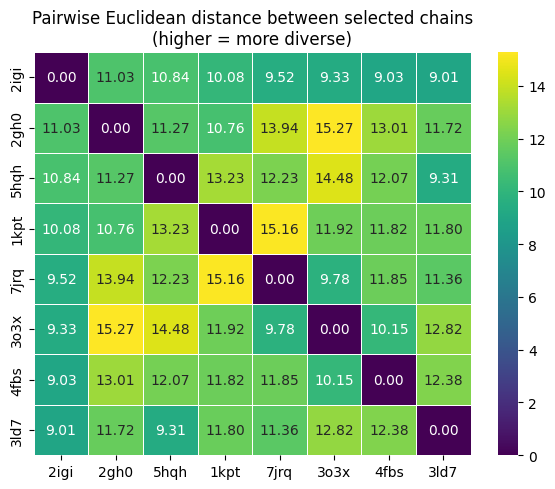

Min pairwise distance between any two selected chains: 9.007
(Higher is better — means no two chains are similar)
Average nearest-neighbour distance in full pool: 3.249
Your selected set min-dist is 2.8x the pool's avg NN distance


In [33]:
import seaborn as sns

X_sel   = X[selected_idx]
D_sel   = cdist(X_sel, X_sel)   # [N_CHAINS, N_CHAINS]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    D_sel, annot=True, fmt=".2f",
    xticklabels=short, yticklabels=short,
    cmap="viridis", ax=ax, linewidths=0.5
)
ax.set_title("Pairwise Euclidean distance between selected chains\n(higher = more diverse)")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/af_native_dynamics_predictor/data/processed/MD_Simulation/V7_atom14_openfold_npz/overfit_subset/diverse_chain_distances.png", dpi=150, bbox_inches="tight")
plt.show()

# Print min off-diagonal distance (worst-case diversity guarantee)
np.fill_diagonal(D_sel, np.inf)
min_dist = D_sel.min()
print(f"Min pairwise distance between any two selected chains: {min_dist:.3f}")
print(f"(Higher is better — means no two chains are similar)")

# Compare to average min-dist in the full pool
D_all  = cdist(X, X)
np.fill_diagonal(D_all, np.inf)
avg_nn_full = D_all.min(axis=1).mean()
print(f"Average nearest-neighbour distance in full pool: {avg_nn_full:.3f}")
print(f"Your selected set min-dist is {min_dist/avg_nn_full:.1f}x the pool's avg NN distance")